# LoRA-based abstractive summarization with FLAN‑T5 and ROUGE evaluation

Modern replacement for the custom TensorFlow LoRA implementation.

- PyTorch FLAN-T5
- Hugging Face PEFT LoRA
- Dynamic padding
- `Seq2SeqTrainer`
- ROUGE evaluation
- Lightweight adapter saving

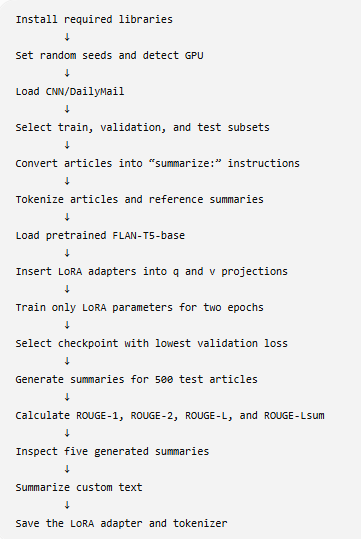

What is genuinely new?

1. Dedicated held-out test evaluation
2. ROUGE metrics

In [ ]:
# Colab setup for text-only Hugging Face workflows.
# torchao/torchvision/timm are optional here and can conflict with Colab's preinstalled PyTorch.
%pip uninstall -y torchao torchvision timm
%pip install -q -U \
    "transformers>=4.57,<6" \
    "datasets>=4,<5" \
    "accelerate>=1.10,<2" \
    "evaluate>=0.4,<1" \
    "sentencepiece>=0.2,<1" \
    "scikit-learn>=1.5,<2"

%pip install -q -U "peft>=0.18,<1" "rouge-score>=0.1,<1"

%pip install -q -U "rouge-score>=0.1,<1"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: timm 1.0.28
Uninstalling timm-1.0.28:
  Successfully uninstalled timm-1.0.28
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 44.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed

In [ ]:
import random
import numpy as np
import torch
import transformers
import datasets
import peft

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.14.1
PEFT: 0.20.0
CUDA available: True


## Load a manageable CNN/DailyMail subset

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

MODEL_NAME = "google/flan-t5-base"
TRAIN_SAMPLES = 10_000
VALIDATION_SAMPLES = 500
TEST_SAMPLES = 500
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

raw_dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")

train_raw = raw_dataset["train"].shuffle(seed=SEED).select(
    range(min(TRAIN_SAMPLES, len(raw_dataset["train"])))
)
validation_raw = raw_dataset["validation"].shuffle(seed=SEED).select(
    range(min(VALIDATION_SAMPLES, len(raw_dataset["validation"])))
)
test_raw = raw_dataset["test"].shuffle(seed=SEED).select(
    range(min(TEST_SAMPLES, len(raw_dataset["test"])))
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_batch(examples):
    inputs = [f"summarize: {article}" for article in examples["article"]]
    targets = examples["highlights"]
    return tokenizer(
        inputs,
        text_target=targets,
        max_length=MAX_INPUT_LENGTH,
        max_target_length=MAX_TARGET_LENGTH,
        truncation=True,
    )

train_dataset = train_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=train_raw.column_names,
)
validation_dataset = validation_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=validation_raw.column_names,
)
test_dataset = test_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=test_raw.column_names,
)

print(train_dataset)
print(train_raw[0])

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

3.0.0/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 10000
})
{'article': "By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Saturday, with investigators saying the three died along with the family's pet dog, of carbon monoxide poisoning from a cooker. Tragic: The inquests have opened into the deaths of three members of the same family who were found in their static caravan last weekend. John and Audrey Cook are pictured . Awful: The family died following carbon monoxide poisoning at this caravan at the Tremarle Home Pa

## Apply LoRA

In [ ]:
from transformers import AutoModelForSeq2SeqLM
from peft import LoraConfig, TaskType, get_peft_model

base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q", "v"],
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 884,736 || all params: 248,462,592 || trainable%: 0.3561


## Train with `Seq2SeqTrainer`

In [ ]:
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_summarization_lora_output",
    num_train_epochs=2,
    learning_rate=5e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=2,
    fp16=use_fp16,
    bf16=use_bf16,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    seed=SEED,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
)

trainer.train()
trainer.evaluate()

Epoch,Training Loss,Validation Loss
1,7.624803,1.593928
2,7.685692,1.591042


Training Loss,Validation Loss,Epoch
7.685692,1.591042,2


{'eval_loss': 1.5910420417785645}

## Evaluate generated summaries with ROUGE

In [ ]:
import numpy as np
import evaluate
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")

# Create a DataLoader using the same sequence-to-sequence collator.
test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=data_collator,
)

# For each batch, it:

# Removes labels before generation.
# Moves the article tokens to the GPU.
# Generates summaries.
# Decodes generated token IDs.
# Decodes the reference labels.
# Stores predictions and references for ROUGE.

# This is a useful demonstration of batched evaluation without relying entirely on Trainer.predict().

model.eval()

predicted_summaries = []
reference_summaries = []

for batch in tqdm(test_dataloader, desc="Generating summaries"):
    # Labels are needed only for reference decoding.
    labels = batch.pop("labels")

    # DataCollatorForSeq2Seq may add decoder_input_ids.
    # These should not be passed to generate().
    batch.pop("decoder_input_ids", None)

    batch = {
        key: value.to(model.device)
        for key, value in batch.items()
    }

    with torch.inference_mode():
        generated_ids = model.generate(
            **batch,
            max_new_tokens=MAX_TARGET_LENGTH,
            num_beams=2,
            early_stopping=True,
        )

    # Move generated token IDs to CPU before decoding.
    generated_ids = generated_ids.cpu().numpy()

    # Replace -100 in reference labels before decoding.
    labels = labels.cpu().numpy()
    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id,
    )

    batch_predictions = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True,
    )

    batch_references = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True,
    )

    predicted_summaries.extend(
        text.strip()
        for text in batch_predictions
    )

    reference_summaries.extend(
        text.strip()
        for text in batch_references
    )

rouge_scores = rouge.compute(
    predictions=predicted_summaries,
    references=reference_summaries,
    use_stemmer=True,
)

print("ROUGE scores:")
for metric, score in rouge_scores.items():
    print(f"{metric}: {score:.4f}")


# Interpretation:

# ROUGE-1: overlap of individual words.
# ROUGE-2: overlap of consecutive two-word sequences.
# ROUGE-L: similarity based on the longest common subsequence.
# ROUGE-Lsum: ROUGE-L adapted to summary-level comparison.

# These scores are based on the notebook’s randomly selected 500-example test subset, not the complete CNN/DailyMail test split.

Generating summaries:   0%|          | 0/125 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

ROUGE scores:
rouge1: 0.4002
rouge2: 0.1775
rougeL: 0.2799
rougeLsum: 0.2805


## Inspect generated summaries

In [ ]:
for i in range(min(5, len(predicted_summaries))):
    print("ARTICLE:")
    print(test_raw[i]["article"][:700], "...")
    print("\nREFERENCE:")
    print(reference_summaries[i])
    print("\nPREDICTION:")
    print(predicted_summaries[i])
    print("\n" + "=" * 100 + "\n")

ARTICLE:
(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the revolution in the eyes of sterling scientists, previously reluctant to dip a toe into this heavily stigmatized world, who are diving in head first. I see it in the new surgeon general who cites data showing just how helpful it can be. I see a revolution in the attitudes of everyday Americans. For the first time a majority, 53%, favor its legalization, with 77% supporting it for medical purposes.  ...

REFERENCE:
CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now . He says he knows how easy it is do nothing "because I did nothing for too long"

PREDICTION:
Marijuana is a medical marijuana revolution in many parts of the country . Marijuana is a medical drug that ca

## Summarize new text

The summarize helper function below performs

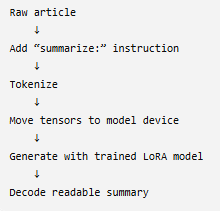

In [ ]:
device = next(model.parameters()).device



def summarize_text(text, max_new_tokens=100):
    inputs = tokenizer(
        f"summarize: {text}",
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LENGTH,
    ).to(device)
    model.eval()
    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=2,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

sample_article = (
    "Researchers introduced a compact method for adapting language models. "
    "Instead of updating every parameter, the method trains small low-rank "
    "matrices inserted into selected layers. This lowers memory use and makes "
    "it easier to store separate adapters for multiple tasks."
)
print(summarize_text(sample_article))

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Researchers introduced a compact method for adapting language models . Instead of updating every parameter, the method trains small low-rank matrices inserted into selected layers . This lowers memory use and makes it easier to store separate adapters for multiple tasks .


## Save only the LoRA adapter

In [ ]:
ADAPTER_DIR = "./flan_t5_summarization_lora_adapter"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Saved adapter to:", ADAPTER_DIR)

Saved adapter to: ./flan_t5_summarization_lora_adapter
